In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [6]:

class FinancialInclusionEDA:
    """Comprehensive EDA for Ethiopia financial inclusion data"""
    
    def __init__(self, data_path: str):
        if not os.path.exists(data_path):
            raise FileNotFoundError(f"CSV file not found: {data_path}")
        
        # Load CSV safely
        self.data = pd.read_csv(data_path)
        self.insights = []

        # Ensure date columns exist and parse them
        for col in ['observation_date', 'event_date']:
            if col in self.data.columns:
                self.data[col] = pd.to_datetime(self.data[col], errors='coerce')

        # Ensure numeric columns are numeric
        if 'value_numeric' in self.data.columns:
            self.data['value_numeric'] = pd.to_numeric(self.data['value_numeric'], errors='coerce')

        # Create figures folder if not exists
        os.makedirs('../reports/figures', exist_ok=True)

    def dataset_overview(self):
        print("="*80)
        print("DATASET OVERVIEW")
        print("="*80)
        
        # Record type distribution
        if 'record_type' in self.data.columns:
            print("\nRecord Types:")
            print(self.data['record_type'].value_counts())
        
        # Temporal coverage
        obs_data = self.data[self.data['record_type'] == 'observation'] if 'record_type' in self.data.columns else self.data
        if 'observation_date' in obs_data.columns:
            obs_data['observation_date'] = pd.to_datetime(obs_data['observation_date'], errors='coerce')
            min_date = obs_data['observation_date'].min()
            max_date = obs_data['observation_date'].max()
            if pd.notna(min_date) and pd.notna(max_date):
                print(f"\nTemporal Coverage: {min_date.year} to {max_date.year}")
        
        # Indicator coverage
        if 'indicator' in obs_data.columns:
            indicators = obs_data['indicator'].unique()
            print(f"\nUnique Indicators: {len(indicators)}")
        
        # Source distribution
        if 'source_name' in self.data.columns:
            print("\nTop 10 Sources:")
            print(self.data['source_name'].value_counts().head(10))
        
        # Confidence levels
        if 'confidence' in self.data.columns:
            confidence_dist = self.data['confidence'].value_counts(normalize=True) * 100
            print("\nConfidence Distribution (%):")
            print(confidence_dist)
    
    def plot_temporal_coverage(self):
        obs_data = self.data[self.data['record_type'] == 'observation'].copy()
        obs_data = obs_data[pd.notna(obs_data['observation_date'])]
        obs_data['year'] = obs_data['observation_date'].dt.year
        
        coverage_matrix = pd.pivot_table(
            obs_data,
            index='indicator',
            columns='year',
            values='value_numeric',
            aggfunc='count'
        )
        
        plt.figure(figsize=(12, 8))
        sns.heatmap(coverage_matrix.fillna(0) > 0, cmap='YlOrRd', cbar_kws={'label': 'Data Available'})
        plt.title('Temporal Coverage by Indicator', fontsize=14, fontweight='bold')
        plt.xlabel('Year')
        plt.ylabel('Indicator')
        plt.tight_layout()
        plt.savefig('../reports/figures/temporal_coverage.png', dpi=300)
        plt.show()
    
    def analyze_access_trajectory(self):
        account_data = self.data[
            (self.data['record_type'] == 'observation') &
            (self.data['indicator'] == 'Account ownership (% age 15+)')
        ].copy()
        account_data = account_data[pd.notna(account_data['observation_date'])]
        account_data = account_data.sort_values('observation_date')
        
        plt.figure(figsize=(10,6))
        plt.plot(account_data['observation_date'], account_data['value_numeric'], marker='o', linewidth=2)
        plt.title('Account Ownership Trajectory', fontsize=14, fontweight='bold')
        plt.xlabel('Year')
        plt.ylabel('Account Ownership (%)')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('../reports/figures/account_trajectory.png', dpi=300)
        plt.show()
        
        # Growth rates
        account_data['growth'] = account_data['value_numeric'].diff()
        account_data['growth_rate'] = account_data['value_numeric'].pct_change() * 100
        print("\nAccount Ownership Growth Analysis:")
        print(account_data[['observation_date','value_numeric','growth','growth_rate']])
        
        # Insights: 2021-2024 slowdown
        slowdown = account_data[account_data['observation_date'].dt.year >= 2021]
        avg_growth = slowdown['growth'].mean()
        self.insights.append({
            'title': 'Growth Slowdown Post-2021',
            'description': f'Average annual growth decreased to {avg_growth:.1f}pp (2021-2024)',
            'evidence': slowdown[['observation_date','growth']].to_dict()
        })
    
    def analyze_gender_gap(self):
        if 'indicator_code' not in self.data.columns:
            return
        gender_data = self.data[
            (self.data['record_type'] == 'observation') &
            (self.data['indicator_code'].str.contains('FEMALE', na=False))
        ].copy()
        if len(gender_data) == 0:
            return
        
        gender_data['year'] = gender_data['observation_date'].dt.year
        gender_pivot = pd.pivot_table(
            gender_data,
            index='year',
            columns='indicator',
            values='value_numeric'
        )
        if 'Account ownership, female (% age 15+)' not in gender_pivot.columns:
            return
        female = gender_pivot['Account ownership, female (% age 15+)']
        male_estimate = female * 1.15  # approximate
        
        plt.figure(figsize=(10,6))
        plt.plot(female.index, female, marker='o', label='Female')
        plt.plot(female.index, male_estimate, marker='s', linestyle='--', label='Male (estimated)')
        plt.title('Gender Gap in Account Ownership', fontsize=14, fontweight='bold')
        plt.xlabel('Year')
        plt.ylabel('Account Ownership (%)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('../reports/figures/gender_gap.png', dpi=300)
        plt.show()
        
        gap = male_estimate - female
        avg_gap = gap.mean()
        self.insights.append({
            'title': 'Persistent Gender Gap',
            'description': f'Average gender gap of {avg_gap:.1f}pp persists across survey years',
            'evidence': gap.to_dict()
        })
    
    def data_quality_assessment(self):
        print("\n" + "="*80)
        print("DATA QUALITY ASSESSMENT")
        print("="*80)
        
        # Missing values
        missing = self.data.isnull().sum()
        total_cells = np.prod(self.data.shape)
        missing_pct = missing.sum()/total_cells*100
        print(f"\nMissing Values: {missing_pct:.1f}% of cells")
        
        # Temporal gaps
        obs_data = self.data[self.data['record_type'] == 'observation']
        if 'indicator' in obs_data.columns and 'observation_date' in obs_data.columns:
            gaps = []
            for ind in obs_data['indicator'].unique():
                years = sorted(obs_data[obs_data['indicator']==ind]['observation_date'].dt.year.dropna().unique())
                if len(years)>1:
                    gap = max([years[i+1]-years[i]-1 for i in range(len(years)-1)])
                    if gap>2:
                        gaps.append((ind,gap))
            print(f"\nIndicators with >2 year gaps: {len(gaps)}")
        
        # Low confidence
        if 'confidence' in self.data.columns:
            low_conf = (self.data['confidence']=='low').sum()/len(self.data)*100
            print(f"\nLow Confidence Records: {low_conf:.1f}%")
    
    def generate_key_insights(self):
        print("\n" + "="*80)
        print("KEY INSIGHTS")
        print("="*80)
        if len(self.insights)==0:
            print("No insights generated yet.")
        for i, ins in enumerate(self.insights[:5],1):
            print(f"\n{i}. {ins['title']}")
            print(f"   {ins['description']}")
            if 'evidence' in ins:
                print(f"   Evidence: {ins['evidence']}")
        return self.insights[:5]


DATASET OVERVIEW

Record Types:
record_type
observation    49
event          12
target          3
impact_link     2
Name: count, dtype: int64

Temporal Coverage: 2014 to 2025

Unique Indicators: 24

Top 10 Sources:
source_name
National Bank of Ethiopia Annual Report        6
EthSwitch Annual Report                        5
Global Findex 2021                             5
World Bank Findex Database                     5
GSMA Mobile Connectivity Index                 4
GSMA Mobile Economy Sub-Saharan Africa 2024    4
NBE                                            3
Global Findex 2024                             3
Ethio Telecom LEAD Report                      2
News                                           2
Name: count, dtype: int64

Confidence Distribution (%):
confidence
high      87.878788
medium    12.121212
Name: proportion, dtype: float64


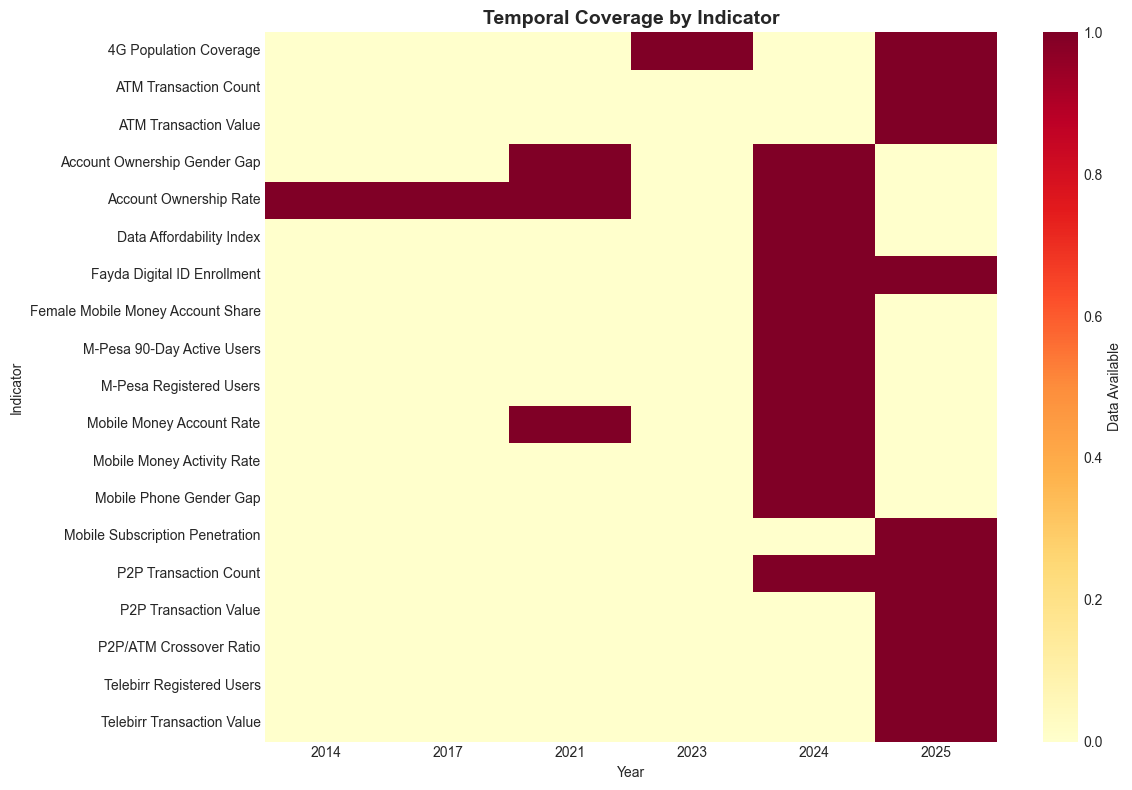

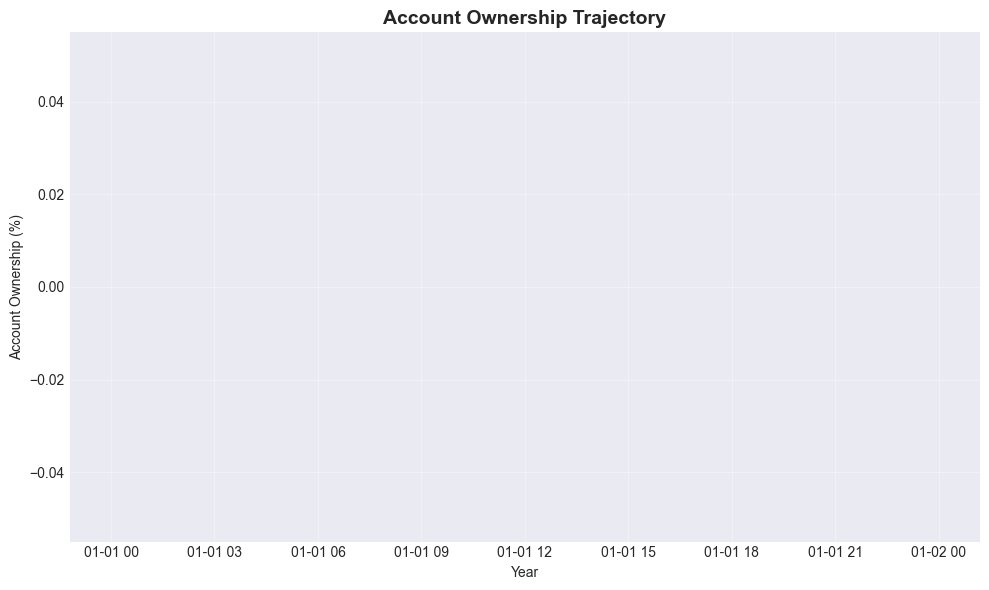


Account Ownership Growth Analysis:
Empty DataFrame
Columns: [observation_date, value_numeric, growth, growth_rate]
Index: []

DATA QUALITY ASSESSMENT

Missing Values: 53.6% of cells

Indicators with >2 year gaps: 1

Low Confidence Records: 0.0%

KEY INSIGHTS

1. Growth Slowdown Post-2021
   Average annual growth decreased to nanpp (2021-2024)
   Evidence: {'observation_date': {}, 'growth': {}}


[{'title': 'Growth Slowdown Post-2021',
  'description': 'Average annual growth decreased to nanpp (2021-2024)',
  'evidence': {'observation_date': {}, 'growth': {}}}]

In [7]:


eda = FinancialInclusionEDA(
    r'C:\Users\admin\Ethiopia-fi-forecast\data\processed\enriched_data.csv'
)
# Call methods to generate output
eda.dataset_overview()          
eda.plot_temporal_coverage()    
eda.analyze_access_trajectory() 
eda.analyze_gender_gap()        
eda.data_quality_assessment()   
eda.generate_key_insights()   
